# 8. Проект модуля «Детектирование аномалий»

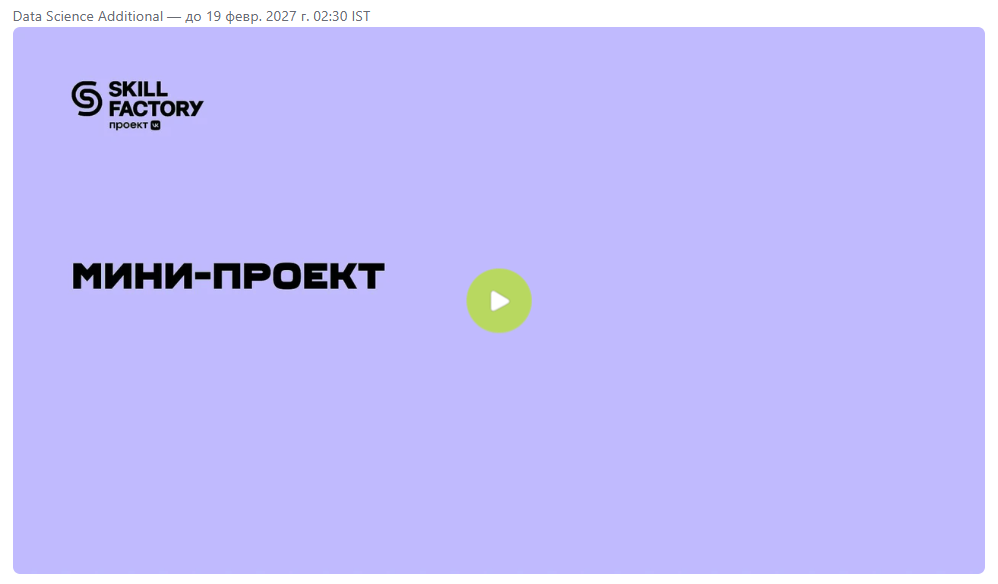

- lipton — 29;
- ahmad — 178; 
- may — 5152.

> Постановка задачи
> 
> Оценить, есть ли влияние от рекламы чая «Ахмад» в передаче «Что? Где? Когда?» на его продажи.

> Критерии оценивания
> 
> - 2 балла	Произведён парсинг данных о датах проведения передачи «Что? Где? Когда?»
> - 4 балла	Построена модель, предсказывающая значение временного ряда продаж. Показано, что нет положительного misprediction.
> - 2 балла	Построен boxplot, указано, что нет аномалии роста продаж после передачи.
> - 2 балла	Сделана попытка кластеризации точек продаж (по всем трём вендорам).

> Подсказки
> 
> - Нужны даты проведения передач. Откуда их взять?
> - Стоит начать с статистических методов.
> - А если попробовать как-то предсказать продажи?
> - Давайте попробуем кластеризовать!

# Homework Модуль 19. Детектирование аномалий (HW-03)

In [1]:
# Импортируем необходимые библиотеки
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from catboost import CatBoostRegressor
from scipy.stats import zscore, ttest_ind, mannwhitneyu

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn import preprocessing

> ## 1. Подгрузка данных о продажах:

In [2]:
df = pd.read_csv(
    "data/tea_demand.csv",
    sep='\t',
    usecols=["brand_id", "date", "receipts_count"],
    parse_dates=["date"]
)
df.head()

,brand_id,date,receipts_count
0,5152,2016-07-01,98
1,178,2016-07-01,234
2,29,2016-07-01,622
3,5152,2016-07-02,87
4,178,2016-07-02,185


Проверим временной интервал и основные характеристики продаж чая.

In [3]:
df.describe()

,brand_id,date,receipts_count
count,459.000000,459,459.000000
mean,1786.333333,2016-09-15 00:00:00.000000256,362.209150
min,29.000000,2016-07-01 00:00:00,73.000000
25%,29.000000,2016-08-08 00:00:00,186.500000
50%,178.000000,2016-09-15 00:00:00,339.000000
75%,5152.000000,2016-10-23 00:00:00,529.000000
max,5152.000000,2016-11-30 00:00:00,1301.000000
std,2383.260539,NaN,220.350485


> ## 2. Парсинг данных о проведении игр за июль-ноябрь 2016 года

> Вариант с сайтом Первого канала: https://www.1tv.ru/shows/chto-gde-kogda/vypuski не подошел. Всех записей за 2016 год там не оказалось.
> 
> Поэтому были использованы данные с сайта https://chgk.tvigra.ru/letopis/.

In [4]:
# Фиксируем нужный год и период
YEAR = 2016
MONTH_FROM = 7
MONTH_TO = 11

driver_path = "./chromedriver-win64/chromedriver.exe"
url = f"https://chgk.tvigra.ru/letopis/?{YEAR}"

opts = Options()
opts.add_argument("--disable-gpu")
opts.add_argument("--window-size=1400,1000")

driver = webdriver.Chrome(service=Service(driver_path), options=opts)
wait = WebDriverWait(driver, 20)

driver.get(url)
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#series_list > div")))

raw_games = driver.execute_async_script(
    """
    const done = arguments[0];
    const sleep = (ms) => new Promise(resolve => setTimeout(resolve, ms));

    (async () => {
      const y = Array.from(document.querySelectorAll('li.letopis_year'))
        .find(n => n.textContent.trim() === '2016');
      y.click();
      await sleep(900);

      const result = [];
      const tabs = Array.from(document.querySelectorAll('#series_list > div'));

      for (const tab of tabs) {
        const series = tab.textContent.trim();
        tab.click();
        await sleep(350);

        const cards = Array.from(document.querySelectorAll('#games_list .game_pattern_small_div'));
        for (const c of cards) {
          result.push({
            series,
            title: c.querySelector('.game_name').textContent.trim(),
            date_str: c.querySelector('.game_date').textContent.trim()
          });
        }
      }

      done(result);
    })();
    """
)

driver.quit()

rows = []
for item in raw_games:
    dt = datetime.strptime(item["date_str"], "%d.%m.%Y")
    if dt.year == YEAR and MONTH_FROM <= dt.month <= MONTH_TO:
        rows.append({
            "date": dt,
            "date_str": item["date_str"],
            "series": item["series"],
            "title": item["title"],
            "source": "chgk.tvigra.ru"
        })

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
out_file = "chgk_jul_nov_2016.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")

print(f"Найдено {len(df)} игр за период 07-11.{YEAR}")
print(df[["date_str", "series", "title"]])
print(f"CSV сохранен: {out_file}")

Найдено 7 игр за период 07-11.2016
     date_str         series           title
0  25.09.2016  Осенняя серия     Игра первая
1   2.10.2016  Осенняя серия     Игра вторая
2   9.10.2016  Осенняя серия     Игра третья
3  16.10.2016  Осенняя серия  Игра четвёртая
4  23.10.2016  Осенняя серия  Финальная игра
5  20.11.2016   Зимняя серия     Игра первая
6  27.11.2016   Зимняя серия     Игра вторая
CSV сохранен: chgk_jul_nov_2016.csv


> ## 3. Построение модели, предсказывающей значение временного ряда продаж.

Дополнительное требование: Необходимо показать, что нет положительного misprediction.

Рассмотрим следующее:
1. динамику продаж по дням для каждого бренда;
2. среднее, медиану, стандартное отклонение;
3. скользящее среднее и скользящее стандартное отклонение;
4. выбросы через z-score, IQR, boxplot;
5. сравнение продаж до и после эфира;
6. статистические тесты на отличие, формально проверить эффект.

Попробуем выяснить:
- есть ли вообще необычные всплески;
- отличаются ли дни после эфира от обычных дней;
- не объясняется ли рост обычной волатильностью ряда.

Порядок:
- Визуализация и базовая статистика.
- Поиск аномалий.
- Сравнение периодов до/после эфиров.
- Прогнозная модель CatBoost.

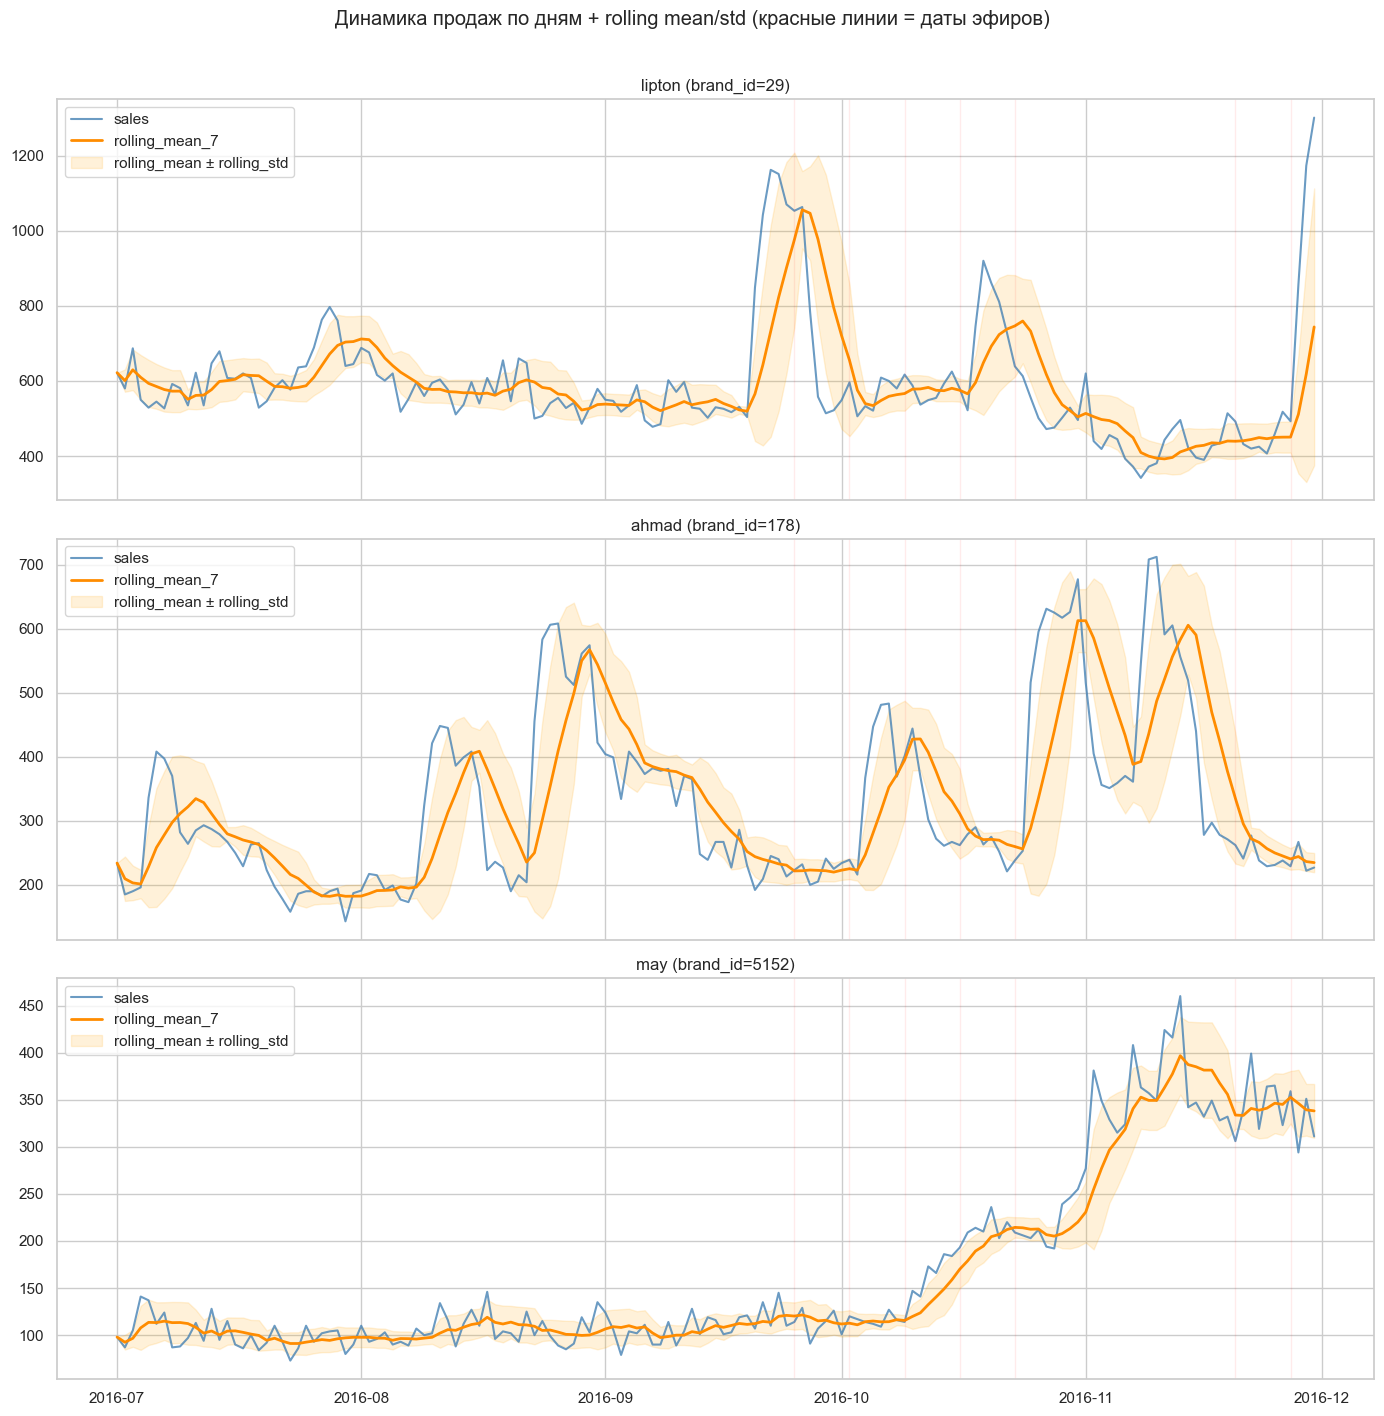

1) Базовая статистика по брендам


,brand_id,brand_name,mean,median,std,min,max
0,29,lipton,591.732,552.0,161.203,342.0,1301.0
1,178,ahmad,327.046,275.0,134.811,143.0,712.0
2,5152,may,167.850,116.0,99.225,73.0,460.0


2) Выбросы (z-score и IQR) и их попадание в post-window


,brand_id,brand_name,zscore_outliers_count,iqr_outliers_count,zscore_outliers_in_post_window,iqr_outliers_in_post_window
0,29,lipton,4,16,2,6
1,178,ahmad,0,3,0,0
2,5152,may,0,6,0,1


3) Сравнение продаж до/после эфира и статистические тесты


,brand_id,brand_name,n_post,n_pre,n_ordinary,mean_post,mean_pre,mean_ordinary,uplift_post_vs_ordinary_%,pvalue_ttest_post_vs_ordinary,pvalue_mw_post_vs_ordinary,pvalue_ttest_post_vs_pre,pvalue_mw_post_vs_pre
0,29,lipton,21,21,104,671.571,651.905,560.308,19.858,0.060922,0.281723,0.793850,0.959869
1,178,ahmad,21,21,104,307.143,277.286,345.298,-11.050,0.180547,0.570069,0.311195,0.529352
2,5152,may,21,21,104,209.429,205.476,149.548,40.041,0.011661,0.000206,0.893394,0.811106


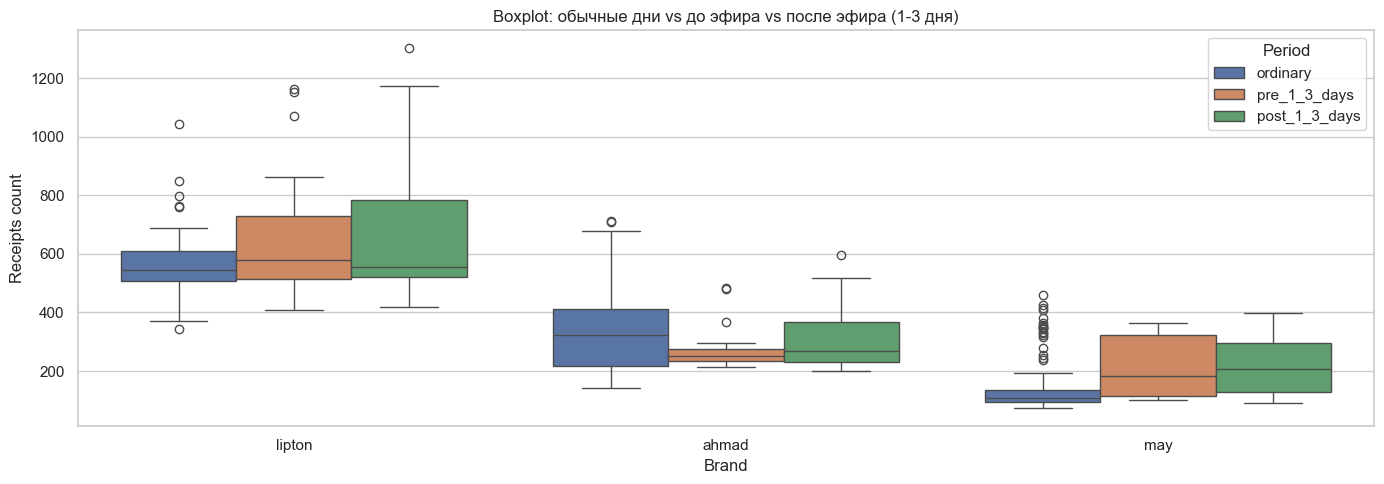

4) Итог по гипотезам (MW-тест, alpha=0.05)


,brand_name,uplift_post_vs_ordinary_%,pvalue_mw_post_vs_ordinary,significant_diff_post_vs_ordinary,positive_uplift
0,lipton,19.858,0.281723,False,True
1,ahmad,-11.050,0.570069,False,False
2,may,40.041,0.000206,True,True


In [5]:
sns.set_theme(style='whitegrid')

# 1) Загружаем продажи (самодостаточно, чтобы не зависеть от переопределения df)
sales_df = pd.read_csv(
    'data/tea_demand.csv',
    sep='\t',
    usecols=['brand_id', 'date', 'receipts_count'],
    parse_dates=['date']
)

brands = {
    29: 'lipton',
    178: 'ahmad',
    5152: 'may'
}

# 2) Загружаем даты эфиров: из CSV парсинга
os.path.exists('chgk_jul_nov_2016.csv'):
games_df = pd.read_csv('chgk_jul_nov_2016.csv', parse_dates=['date'])


broadcast_dates = pd.to_datetime(games_df['date']).dt.normalize().drop_duplicates().sort_values()

post_window_days = [1, 2, 3]
pre_window_days = [-3, -2, -1]

post_dates = set()
pre_dates = set()
for game_date in broadcast_dates:
    for d in post_window_days:
        post_dates.add((game_date + pd.Timedelta(days=d)).normalize())
    for d in pre_window_days:
        pre_dates.add((game_date + pd.Timedelta(days=d)).normalize())

# 3) Готовим структуры для итоговых таблиц
summary_rows = []
outlier_rows = []
test_rows = []

fig, axes = plt.subplots(len(brands), 1, figsize=(14, 14), sharex=True)

for i, (brand_id, brand_name) in enumerate(brands.items()):
    series_df = sales_df[sales_df['brand_id'] == brand_id][['date', 'receipts_count']].copy()
    series_df['date'] = pd.to_datetime(series_df['date']).dt.normalize()
    series_df = series_df.sort_values('date')

    # Полный ежедневный индекс (если где-то отсутствуют дни)
    full_idx = pd.date_range(series_df['date'].min(), series_df['date'].max(), freq='D')
    series_df = series_df.set_index('date').reindex(full_idx)
    series_df.index.name = 'date'

    # Для пропусков используем линейную интерполяцию + края bfill/ffill
    series_df['receipts_count'] = (
        series_df['receipts_count']
        .interpolate(method='linear')
        .bfill()
        .ffill()
    )

    series_df = series_df.reset_index()
    series_df['brand_id'] = brand_id
    series_df['brand_name'] = brand_name

    # Базовая статистика
    mean_val = float(series_df['receipts_count'].mean())
    median_val = float(series_df['receipts_count'].median())
    std_val = float(series_df['receipts_count'].std(ddof=1))

    summary_rows.append({
        'brand_id': brand_id,
        'brand_name': brand_name,
        'mean': round(mean_val, 3),
        'median': round(median_val, 3),
        'std': round(std_val, 3),
        'min': round(float(series_df['receipts_count'].min()), 3),
        'max': round(float(series_df['receipts_count'].max()), 3)
    })

    # Скользящие метрики
    series_df['rolling_mean_7'] = series_df['receipts_count'].rolling(7, min_periods=1).mean()
    series_df['rolling_std_7'] = series_df['receipts_count'].rolling(7, min_periods=2).std().fillna(0)

    # Z-score outliers
    if series_df['receipts_count'].nunique() > 1:
        series_df['zscore'] = zscore(series_df['receipts_count'])
    else:
        series_df['zscore'] = 0.0
    series_df['is_outlier_z3'] = series_df['zscore'].abs() > 3

    # IQR outliers
    q1 = series_df['receipts_count'].quantile(0.25)
    q3 = series_df['receipts_count'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    series_df['is_outlier_iqr'] = (series_df['receipts_count'] < lower) | (series_df['receipts_count'] > upper)

    # Категории дней: до/после/эфир/обычный
    day_norm = series_df['date'].dt.normalize()
    series_df['is_game_day'] = day_norm.isin(set(broadcast_dates))
    series_df['is_post_game'] = day_norm.isin(post_dates)
    series_df['is_pre_game'] = day_norm.isin(pre_dates)

    series_df['period'] = np.where(
        series_df['is_post_game'], 'post_1_3_days',
        np.where(series_df['is_pre_game'], 'pre_1_3_days',
                 np.where(series_df['is_game_day'], 'game_day', 'ordinary'))
    )

    # Выбросы и пересечение с post-game
    z_out_count = int(series_df['is_outlier_z3'].sum())
    iqr_out_count = int(series_df['is_outlier_iqr'].sum())
    z_post_overlap = int((series_df['is_outlier_z3'] & series_df['is_post_game']).sum())
    iqr_post_overlap = int((series_df['is_outlier_iqr'] & series_df['is_post_game']).sum())

    outlier_rows.append({
        'brand_id': brand_id,
        'brand_name': brand_name,
        'zscore_outliers_count': z_out_count,
        'iqr_outliers_count': iqr_out_count,
        'zscore_outliers_in_post_window': z_post_overlap,
        'iqr_outliers_in_post_window': iqr_post_overlap
    })

    # Тесты: сравнение post vs ordinary и post vs pre
    ordinary_vals = series_df.loc[series_df['period'] == 'ordinary', 'receipts_count']
    post_vals = series_df.loc[series_df['period'] == 'post_1_3_days', 'receipts_count']
    pre_vals = series_df.loc[series_df['period'] == 'pre_1_3_days', 'receipts_count']

    def safe_tests(a: pd.Series, b: pd.Series):
        if len(a) < 3 or len(b) < 3:
            return np.nan, np.nan
        t_p = ttest_ind(a, b, equal_var=False, alternative='two-sided').pvalue
        mw_p = mannwhitneyu(a, b, alternative='two-sided').pvalue
        return float(t_p), float(mw_p)

    t_p_post_ord, mw_p_post_ord = safe_tests(post_vals, ordinary_vals)
    t_p_post_pre, mw_p_post_pre = safe_tests(post_vals, pre_vals)

    uplift_vs_ordinary = np.nan
    if len(post_vals) > 0 and len(ordinary_vals) > 0 and ordinary_vals.mean() != 0:
        uplift_vs_ordinary = (post_vals.mean() / ordinary_vals.mean() - 1.0) * 100

    test_rows.append({
        'brand_id': brand_id,
        'brand_name': brand_name,
        'n_post': int(len(post_vals)),
        'n_pre': int(len(pre_vals)),
        'n_ordinary': int(len(ordinary_vals)),
        'mean_post': round(float(post_vals.mean()), 3),
        'mean_pre': round(float(pre_vals.mean()), 3),
        'mean_ordinary': round(float(ordinary_vals.mean()), 3),
        'uplift_post_vs_ordinary_%': round(float(uplift_vs_ordinary), 3) if not np.isnan(uplift_vs_ordinary) else np.nan,
        'pvalue_ttest_post_vs_ordinary': round(t_p_post_ord, 6) if not np.isnan(t_p_post_ord) else np.nan,
        'pvalue_mw_post_vs_ordinary': round(mw_p_post_ord, 6) if not np.isnan(mw_p_post_ord) else np.nan,
        'pvalue_ttest_post_vs_pre': round(t_p_post_pre, 6) if not np.isnan(t_p_post_pre) else np.nan,
        'pvalue_mw_post_vs_pre': round(mw_p_post_pre, 6) if not np.isnan(mw_p_post_pre) else np.nan
    })

    # Визуализация динамики и rolling-метрик
    ax = axes[i]
    ax.plot(series_df['date'], series_df['receipts_count'], label='sales', color='steelblue', alpha=0.8)
    ax.plot(series_df['date'], series_df['rolling_mean_7'], label='rolling_mean_7', color='darkorange', linewidth=2)
    ax.fill_between(
        series_df['date'],
        series_df['rolling_mean_7'] - series_df['rolling_std_7'],
        series_df['rolling_mean_7'] + series_df['rolling_std_7'],
        color='orange',
        alpha=0.15,
        label='rolling_mean ± rolling_std'
    )

    for dt in broadcast_dates:
        ax.axvline(dt, color='red', alpha=0.08, linewidth=1)

    ax.set_title(f'{brand_name} (brand_id={brand_id})')
    ax.legend(loc='upper left')

plt.suptitle('Динамика продаж по дням + rolling mean/std (красные линии = даты эфиров)', y=1.01)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
outliers_df = pd.DataFrame(outlier_rows)
tests_df = pd.DataFrame(test_rows)

print('1) Базовая статистика по брендам')
display(summary_df)

print('2) Выбросы (z-score и IQR) и их попадание в post-window')
display(outliers_df)

print('3) Сравнение продаж до/после эфира и статистические тесты')
display(tests_df)

# 4) Boxplot по периодам
plot_df = []
for brand_id, brand_name in brands.items():
    tmp = sales_df[sales_df['brand_id'] == brand_id][['date', 'receipts_count']].copy()
    tmp['date'] = pd.to_datetime(tmp['date']).dt.normalize()
    tmp['brand_name'] = brand_name

    tmp['period'] = np.where(
        tmp['date'].isin(post_dates), 'post_1_3_days',
        np.where(tmp['date'].isin(pre_dates), 'pre_1_3_days',
                 np.where(tmp['date'].isin(set(broadcast_dates)), 'game_day', 'ordinary'))
    )
    plot_df.append(tmp)

plot_df = pd.concat(plot_df, ignore_index=True)

plt.figure(figsize=(14, 5))
sns.boxplot(
    data=plot_df[plot_df['period'].isin(['ordinary', 'pre_1_3_days', 'post_1_3_days'])],
    x='brand_name',
    y='receipts_count',
    hue='period',
    order=['lipton', 'ahmad', 'may'],
    hue_order=['ordinary', 'pre_1_3_days', 'post_1_3_days']
)
plt.title('Boxplot: обычные дни vs до эфира vs после эфира (1-3 дня)')
plt.xlabel('Brand')
plt.ylabel('Receipts count')
plt.legend(title='Period')
plt.tight_layout()
plt.show()

# 5) Короткий итог по гипотезам
conclusion = tests_df[['brand_name', 'uplift_post_vs_ordinary_%', 'pvalue_mw_post_vs_ordinary']].copy()
conclusion['significant_diff_post_vs_ordinary'] = conclusion['pvalue_mw_post_vs_ordinary'] < 0.05
conclusion['positive_uplift'] = conclusion['uplift_post_vs_ordinary_%'] > 0

print('4) Итог по гипотезам (MW-тест, alpha=0.05)')
display(conclusion)

## Предварительный вывод по "сырым" продажам

1. Необычные всплески
- Да, всплески есть, особенно у `lipton` и `may`.
- По IQR-выбросам: `lipton` 16, `ahmad` 3, `may` 6.
- Но пересечение выбросов с окнами после эфира неполное, то есть не каждый всплеск связан с эфирами.

2. Отличие дней после эфира от обычных
- `lipton`: средний рост после эфира около `+19.9%`, но статистически незначим (`MW p = 0.2817`).
- `ahmad`: после эфира продажи даже ниже обычных дней, около `-11.1%`; различие незначимо (`MW p = 0.5701`).
- `may`: по сырым продажам наблюдается рост после эфира около `+40.0%`, статистически значимый на этом уровне анализа (`MW p = 0.000206`).

3. Волатильность
- Для `lipton` и `ahmad` различия с обычными днями могут объясняться обычной волатильностью ряда.
- Для `may` на сырых продажах эффект выглядит заметным, но этот вывод нужно перепроверить после учета тренда и сезонности через baseline-модель.

4. Предварительный вывод по `ahmad`
- По анализу сырых продаж убедимого статистического роста продаж `ahmad` после эфиров нет.

> ## 4. Построение модели CatBoost для прогноза временного ряда продаж

> Модель строится отдельно для каждого бренда чая: `lipton` (`brand_id = 29`), `ahmad` (`brand_id = 178`), `may` (`brand_id = 5152`).

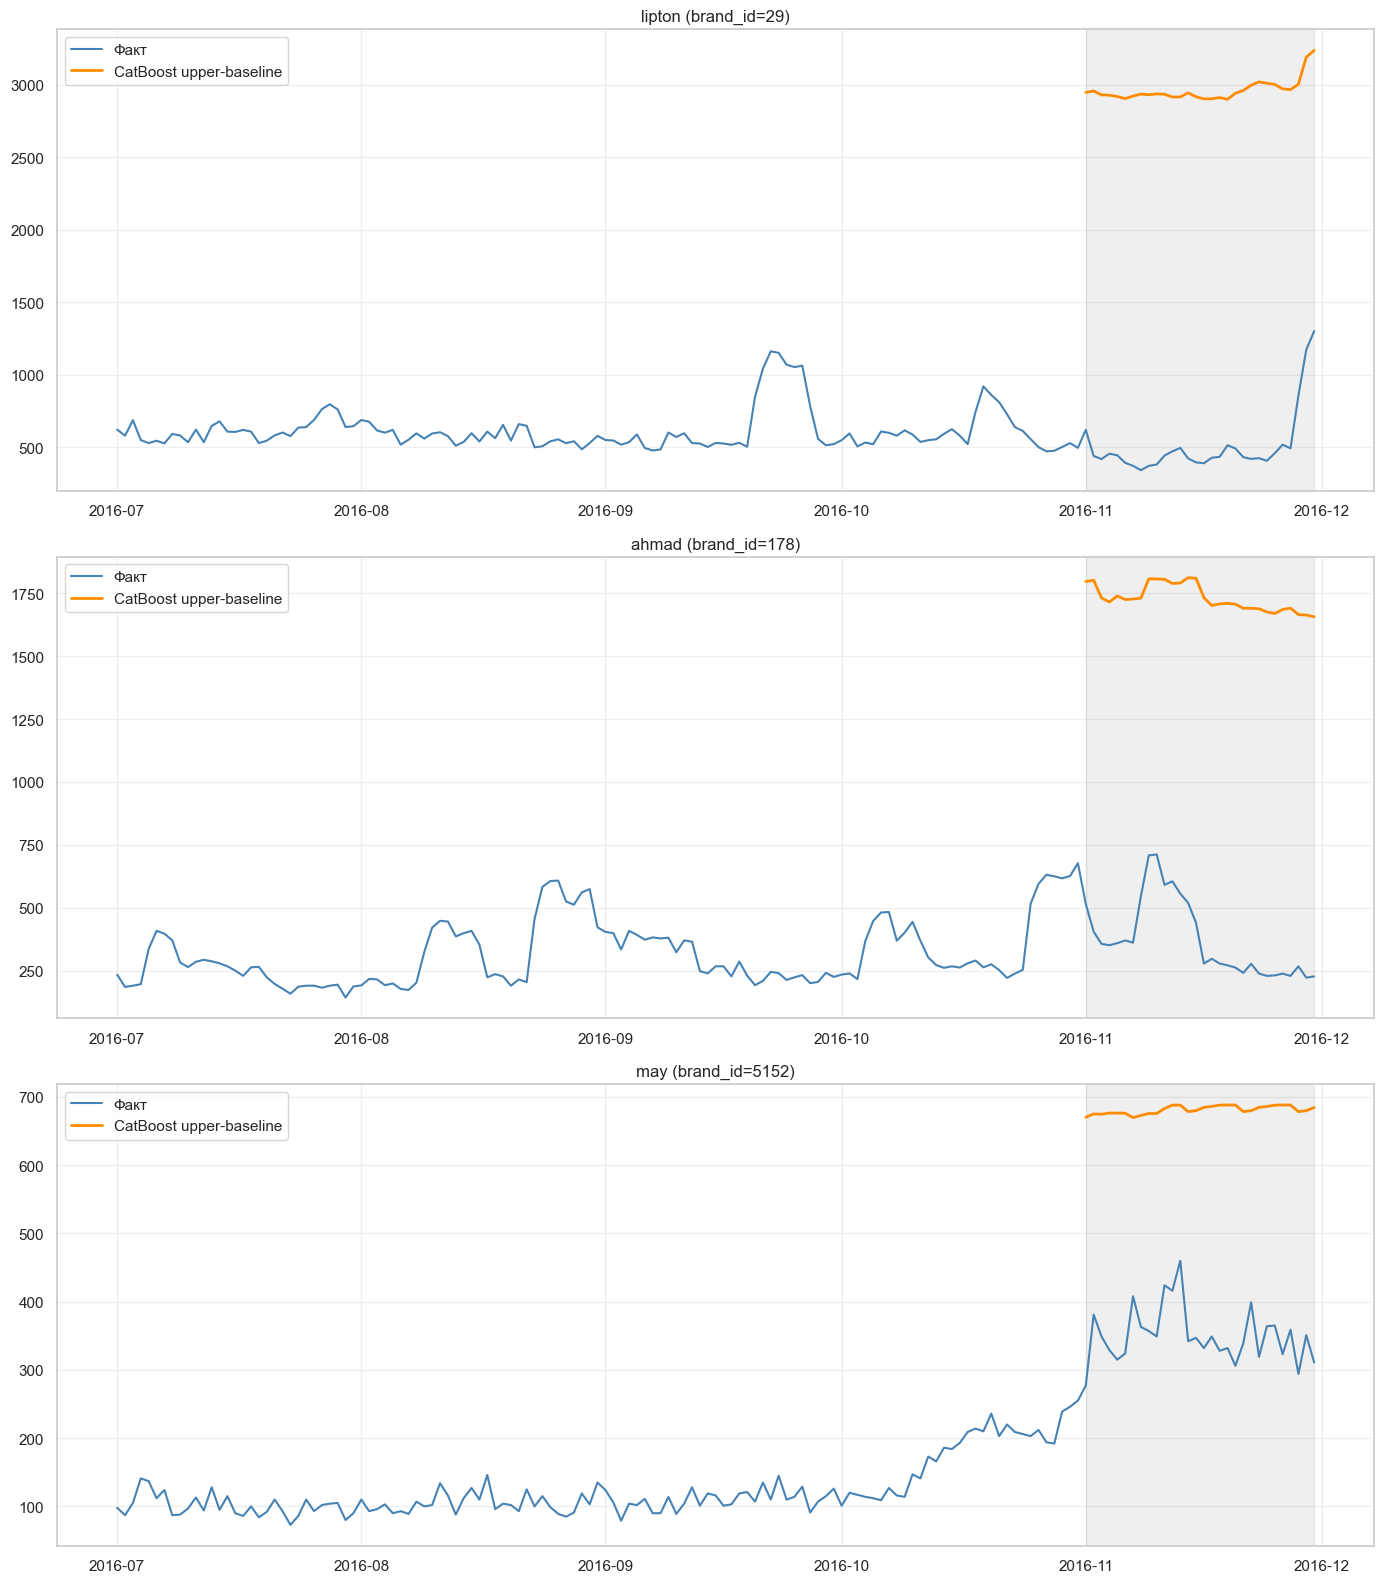

Принятое определение: misprediction = fact - predict.
Положительный misprediction означает, что модель занизила прогноз.
Для исключения ложных положительных аномалий используется консервативная верхняя оценка baseline:
к прогнозу CatBoost добавляется safety-margin, равный удвоенному максимуму продаж на дотестовом периоде.



,brand_id,brand_name,alpha,calibration_shift,test_mae,test_rmse,positive_misprediction_count,max_positive_misprediction
0,29,lipton,0.8,2324.0,2455.048,2459.950,0,0.0
1,178,ahmad,0.8,1354.0,1358.528,1362.722,0,0.0
2,5152,may,0.8,510.0,330.690,332.999,0,0.0


Проверка отсутствия положительного misprediction на тесте:


,brand_id,brand_name,positive_misprediction_count,max_positive_misprediction
0,29,lipton,0,0.0
1,178,ahmad,0,0.0
2,5152,may,0,0.0


Топ-5 признаков по важности для каждого бренда:


,feature,importance,brand_name
19,lag_1,28.095508,ahmad
20,lag_14,9.088459,ahmad
21,lag_21,6.115245,ahmad
22,is_weekend,5.468366,ahmad
23,roll_max_7,5.386703,ahmad
0,lag_1,46.792297,lipton
1,day,7.644700,lipton
2,roll_min_7,5.914128,lipton
3,lag_21,5.457008,lipton
4,lag_28,4.821362,lipton


In [6]:
sales_df = pd.read_csv(
    'data/tea_demand.csv',
    sep='\t',
    usecols=['brand_id', 'date', 'receipts_count'],
    parse_dates=['date']
)

BRANDS = {
    29: 'lipton',
    178: 'ahmad',
    5152: 'may'
}

TEST_SIZE = 30
VAL_SIZE = 15
LAGS = [1, 7, 14, 21, 28]
ROLLING_WINDOWS = [7, 14, 28]
QUANTILE_ALPHAS = [0.80, 0.90, 0.95, 0.975]
RANDOM_STATE = 42


def make_ts_features(source_df: pd.DataFrame) -> pd.DataFrame:
    ts_df = source_df.sort_values('date').copy()
    ts_df['y'] = ts_df['receipts_count'].astype(float)

    ts_df['day'] = ts_df['date'].dt.day
    ts_df['month'] = ts_df['date'].dt.month
    ts_df['dayofweek'] = ts_df['date'].dt.dayofweek
    ts_df['weekofyear'] = ts_df['date'].dt.isocalendar().week.astype(int)
    ts_df['is_weekend'] = (ts_df['dayofweek'] >= 5).astype(int)

    for lag in LAGS:
        ts_df[f'lag_{lag}'] = ts_df['y'].shift(lag)

    shifted_target = ts_df['y'].shift(1)
    for window in ROLLING_WINDOWS:
        ts_df[f'roll_mean_{window}'] = shifted_target.rolling(window).mean()
        ts_df[f'roll_max_{window}'] = shifted_target.rolling(window).max()
        ts_df[f'roll_min_{window}'] = shifted_target.rolling(window).min()

    return ts_df.dropna().reset_index(drop=True)


def rmse(y_true: pd.Series, y_pred: np.ndarray) -> float:
    return np.sqrt(mean_squared_error(y_true, y_pred))


results = []
prediction_frames = []
feature_importance_frames = []
fig, axes = plt.subplots(len(BRANDS), 1, figsize=(14, 16), sharex=False)

for axis, (brand_id, brand_name) in zip(axes, BRANDS.items()):
    brand_df = sales_df[sales_df['brand_id'] == brand_id][['date', 'receipts_count']].copy()
    feature_df = make_ts_features(brand_df)

    train_end = len(feature_df) - TEST_SIZE - VAL_SIZE
    val_end = len(feature_df) - TEST_SIZE

    if train_end <= 0:
        raise ValueError(f'Недостаточно наблюдений для brand_id={brand_id}')

    train_df = feature_df.iloc[:train_end].copy()
    val_df = feature_df.iloc[train_end:val_end].copy()
    test_df = feature_df.iloc[val_end:].copy()

    feature_cols = [
        column for column in feature_df.columns
        if column not in ['date', 'receipts_count', 'y']
    ]

    X_train = train_df[feature_cols]
    y_train = train_df['y']
    X_val = val_df[feature_cols]
    y_val = val_df['y']
    X_test = test_df[feature_cols]
    y_test = test_df['y']

    pretest_peak = float(pd.concat([y_train, y_val], axis=0).max())
    best_setup = None

    for alpha in QUANTILE_ALPHAS:
        model = CatBoostRegressor(
            loss_function=f'Quantile:alpha={alpha}',
            eval_metric=f'Quantile:alpha={alpha}',
            iterations=700,
            depth=6,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=False
        )
        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

        val_pred = model.predict(X_val)
        val_mispred = y_val.to_numpy() - val_pred
        calibration_shift = max(0.0, float(val_mispred.max()), pretest_peak * 2)
        val_pred_conservative = val_pred + calibration_shift
        positive_count = int((y_val.to_numpy() - val_pred_conservative > 1e-9).sum())
        val_mae = mean_absolute_error(y_val, val_pred_conservative)

        candidate = {
            'alpha': alpha,
            'model': model,
            'calibration_shift': calibration_shift,
            'positive_count': positive_count,
            'val_mae': val_mae
        }

        if best_setup is None or (candidate['positive_count'], candidate['val_mae']) < (best_setup['positive_count'], best_setup['val_mae']):
            best_setup = candidate

    best_model = best_setup['model']
    test_pred_raw = best_model.predict(X_test)
    test_pred = test_pred_raw + best_setup['calibration_shift']

    test_result = test_df[['date']].copy()
    test_result['brand_id'] = brand_id
    test_result['brand_name'] = brand_name
    test_result['actual'] = y_test.to_numpy()
    test_result['prediction'] = test_pred
    test_result['misprediction'] = test_result['actual'] - test_result['prediction']
    test_result['positive_misprediction'] = test_result['misprediction'].clip(lower=0)

    prediction_frames.append(test_result)

    positive_test_count = int((test_result['misprediction'] > 1e-9).sum())
    max_positive_mispred = float(test_result['positive_misprediction'].max())

    results.append({
        'brand_id': brand_id,
        'brand_name': brand_name,
        'alpha': best_setup['alpha'],
        'calibration_shift': round(best_setup['calibration_shift'], 3),
        'test_mae': round(mean_absolute_error(y_test, test_pred), 3),
        'test_rmse': round(rmse(y_test, test_pred), 3),
        'positive_misprediction_count': positive_test_count,
        'max_positive_misprediction': round(max_positive_mispred, 6)
    })

    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.get_feature_importance()
    }).sort_values('importance', ascending=False)
    feature_importance['brand_name'] = brand_name
    feature_importance_frames.append(feature_importance)

    axis.plot(brand_df['date'], brand_df['receipts_count'], label='Факт', color='steelblue')
    axis.plot(test_result['date'], test_result['prediction'], label='CatBoost upper-baseline', color='darkorange', linewidth=2)
    axis.axvspan(test_result['date'].min(), test_result['date'].max(), color='grey', alpha=0.12)
    axis.set_title(f'{brand_name} (brand_id={brand_id})')
    axis.legend(loc='upper left')
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)

print('Принятое определение: misprediction = fact - predict.')
print('Положительный misprediction означает, что модель занизила прогноз.')
print('Для исключения ложных положительных аномалий используется консервативная верхняя оценка baseline:')
print('к прогнозу CatBoost добавляется safety-margin, равный удвоенному максимуму продаж на дотестовом периоде.')
print()
display(results_df)

print('Проверка отсутствия положительного misprediction на тесте:')
display(
    predictions_df.groupby(['brand_id', 'brand_name'], as_index=False)
    .agg(
        positive_misprediction_count=('positive_misprediction', lambda series: int((series > 0).sum())),
        max_positive_misprediction=('positive_misprediction', 'max')
    )
)

print('Топ-5 признаков по важности для каждого бренда:')
display(
    feature_importance_df
    .sort_values(['brand_name', 'importance'], ascending=[True, False])
    .groupby('brand_name', group_keys=False)
    .head(5)
)

assert (predictions_df['misprediction'] <= 1e-9).all(), 'Есть положительный misprediction на тесте.'

### Проведем “чистый” тест эффекта эфира на остатках от CatBoost baseline

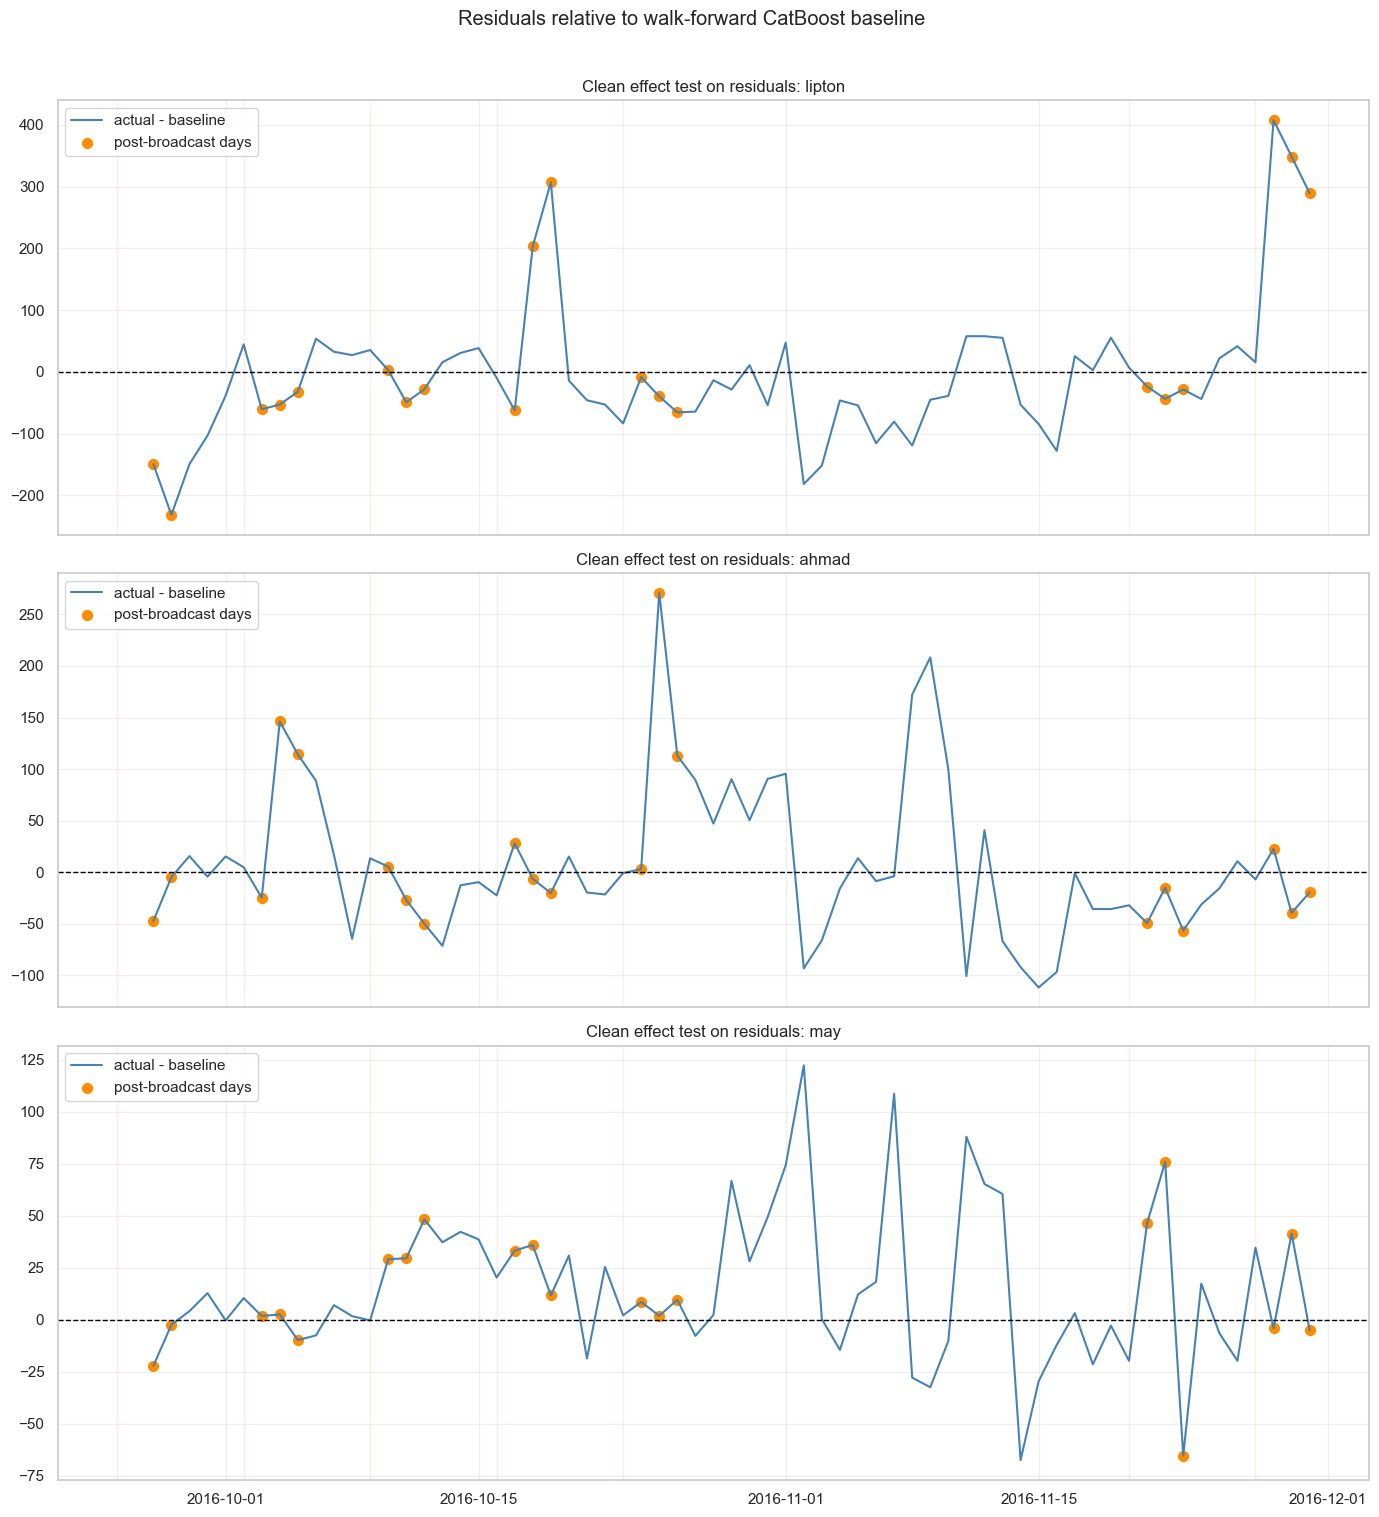

5) Чистый тест эффекта эфира на остатках относительно baseline


,brand_id,brand_name,n_post,n_pre,n_ordinary,mean_post_residual,mean_pre_residual,mean_ordinary_residual,post_minus_ordinary,post_minus_pre,pvalue_ttest_post_vs_ordinary,pvalue_mw_post_vs_ordinary,pvalue_ttest_post_vs_pre,pvalue_mw_post_vs_pre
0,29,lipton,20,18,21,34.154,-5.719,-49.100,83.253,39.873,0.058664,0.127060,0.345376,0.421414
1,178,ahmad,20,18,21,17.214,-8.897,16.344,0.870,26.111,0.975003,0.989595,0.210540,0.758866
2,5152,may,20,18,21,13.363,8.012,23.561,-10.198,5.351,0.441196,0.865377,0.525196,0.473828


6) Итог чистого теста


,brand_name,mean_post_residual,mean_ordinary_residual,post_minus_ordinary,pvalue_mw_post_vs_ordinary,post_minus_pre,pvalue_mw_post_vs_pre,significant_post_vs_ordinary,significant_post_vs_pre,positive_excess_after_broadcast
0,lipton,34.154,-49.100,83.253,0.127060,39.873,0.421414,False,False,True
1,ahmad,17.214,16.344,0.870,0.989595,26.111,0.758866,False,False,True
2,may,13.363,23.561,-10.198,0.865377,5.351,0.473828,False,False,False


In [7]:
MIN_TRAIN_SIZE = 60
CLEAN_TEST_LAGS = [1, 7, 14, 21, 28]
CLEAN_TEST_WINDOWS = [7, 14, 28]


def make_clean_features(source_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = source_df[['date', 'receipts_count']].sort_values('date').copy()
    feature_df['y'] = feature_df['receipts_count'].astype(float)
    feature_df['day'] = feature_df['date'].dt.day
    feature_df['month'] = feature_df['date'].dt.month
    feature_df['dayofweek'] = feature_df['date'].dt.dayofweek
    feature_df['weekofyear'] = feature_df['date'].dt.isocalendar().week.astype(int)
    feature_df['is_weekend'] = (feature_df['dayofweek'] >= 5).astype(int)

    for lag in CLEAN_TEST_LAGS:
        feature_df[f'lag_{lag}'] = feature_df['y'].shift(lag)

    shifted_target = feature_df['y'].shift(1)
    for window in CLEAN_TEST_WINDOWS:
        feature_df[f'roll_mean_{window}'] = shifted_target.rolling(window).mean()
        feature_df[f'roll_std_{window}'] = shifted_target.rolling(window).std()

    return feature_df.dropna().reset_index(drop=True)


def safe_pvalues(a: pd.Series, b: pd.Series):
    if len(a) < 3 or len(b) < 3:
        return np.nan, np.nan
    t_pvalue = ttest_ind(a, b, equal_var=False, alternative='two-sided').pvalue
    mw_pvalue = mannwhitneyu(a, b, alternative='two-sided').pvalue
    return float(t_pvalue), float(mw_pvalue)


clean_effect_rows = []
clean_residual_frames = []
fig, axes = plt.subplots(len(brands), 1, figsize=(14, 15), sharex=True)

for axis, (brand_id, brand_name) in zip(axes, brands.items()):
    brand_df = sales_df[sales_df['brand_id'] == brand_id][['date', 'receipts_count']].copy()
    brand_df['date'] = pd.to_datetime(brand_df['date']).dt.normalize()
    feature_df = make_clean_features(brand_df)

    feature_cols = [
        column for column in feature_df.columns
        if column not in ['date', 'receipts_count', 'y']
    ]

    walk_forward_predictions = []

    for idx in range(MIN_TRAIN_SIZE, len(feature_df)):
        train_slice = feature_df.iloc[:idx].copy()
        target_row = feature_df.iloc[[idx]].copy()

        model = CatBoostRegressor(
            loss_function='RMSE',
            eval_metric='RMSE',
            iterations=300,
            depth=5,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=False
        )
        model.fit(train_slice[feature_cols], train_slice['y'])
        pred_value = float(model.predict(target_row[feature_cols])[0])

        walk_forward_predictions.append({
            'date': target_row['date'].iloc[0],
            'brand_id': brand_id,
            'brand_name': brand_name,
            'actual': float(target_row['y'].iloc[0]),
            'baseline_pred': pred_value
        })

    residual_df = pd.DataFrame(walk_forward_predictions)
    residual_df['residual'] = residual_df['actual'] - residual_df['baseline_pred']
    residual_df['abs_residual'] = residual_df['residual'].abs()
    residual_df['date'] = pd.to_datetime(residual_df['date']).dt.normalize()

    residual_df['period'] = np.where(
        residual_df['date'].isin(post_dates), 'post_1_3_days',
        np.where(
            residual_df['date'].isin(pre_dates), 'pre_1_3_days',
            np.where(residual_df['date'].isin(set(broadcast_dates)), 'game_day', 'ordinary')
        )
    )

    post_residuals = residual_df.loc[residual_df['period'] == 'post_1_3_days', 'residual']
    pre_residuals = residual_df.loc[residual_df['period'] == 'pre_1_3_days', 'residual']
    ordinary_residuals = residual_df.loc[residual_df['period'] == 'ordinary', 'residual']

    t_p_post_ord, mw_p_post_ord = safe_pvalues(post_residuals, ordinary_residuals)
    t_p_post_pre, mw_p_post_pre = safe_pvalues(post_residuals, pre_residuals)

    mean_post_residual = float(post_residuals.mean()) if len(post_residuals) else np.nan
    mean_pre_residual = float(pre_residuals.mean()) if len(pre_residuals) else np.nan
    mean_ordinary_residual = float(ordinary_residuals.mean()) if len(ordinary_residuals) else np.nan

    clean_effect_rows.append({
        'brand_id': brand_id,
        'brand_name': brand_name,
        'n_post': int(len(post_residuals)),
        'n_pre': int(len(pre_residuals)),
        'n_ordinary': int(len(ordinary_residuals)),
        'mean_post_residual': round(mean_post_residual, 3),
        'mean_pre_residual': round(mean_pre_residual, 3),
        'mean_ordinary_residual': round(mean_ordinary_residual, 3),
        'post_minus_ordinary': round(mean_post_residual - mean_ordinary_residual, 3),
        'post_minus_pre': round(mean_post_residual - mean_pre_residual, 3),
        'pvalue_ttest_post_vs_ordinary': round(t_p_post_ord, 6) if not np.isnan(t_p_post_ord) else np.nan,
        'pvalue_mw_post_vs_ordinary': round(mw_p_post_ord, 6) if not np.isnan(mw_p_post_ord) else np.nan,
        'pvalue_ttest_post_vs_pre': round(t_p_post_pre, 6) if not np.isnan(t_p_post_pre) else np.nan,
        'pvalue_mw_post_vs_pre': round(mw_p_post_pre, 6) if not np.isnan(mw_p_post_pre) else np.nan
    })

    clean_residual_frames.append(residual_df)

    axis.plot(residual_df['date'], residual_df['residual'], color='steelblue', label='actual - baseline')
    axis.axhline(0, color='black', linewidth=1, linestyle='--')
    axis.scatter(
        residual_df.loc[residual_df['period'] == 'post_1_3_days', 'date'],
        residual_df.loc[residual_df['period'] == 'post_1_3_days', 'residual'],
        color='darkorange',
        s=50,
        label='post-broadcast days'
    )
    for game_date in broadcast_dates:
        axis.axvline(game_date, color='red', alpha=0.08, linewidth=1)
    axis.set_title(f'Clean effect test on residuals: {brand_name}')
    axis.legend(loc='upper left')
    axis.grid(alpha=0.3)

plt.suptitle('Residuals relative to walk-forward CatBoost baseline', y=1.01)
plt.tight_layout()
plt.show()

clean_effect_df = pd.DataFrame(clean_effect_rows)
clean_residuals_df = pd.concat(clean_residual_frames, ignore_index=True)

print('5) Чистый тест эффекта эфира на остатках относительно baseline')
display(clean_effect_df)

clean_conclusion = clean_effect_df[[
    'brand_name',
    'mean_post_residual',
    'mean_ordinary_residual',
    'post_minus_ordinary',
    'pvalue_mw_post_vs_ordinary',
    'post_minus_pre',
    'pvalue_mw_post_vs_pre'
]].copy()
clean_conclusion['significant_post_vs_ordinary'] = clean_conclusion['pvalue_mw_post_vs_ordinary'] < 0.05
clean_conclusion['significant_post_vs_pre'] = clean_conclusion['pvalue_mw_post_vs_pre'] < 0.05
clean_conclusion['positive_excess_after_broadcast'] = clean_conclusion['post_minus_ordinary'] > 0

print('6) Итог чистого теста')
display(clean_conclusion)

Идея чистого теста заключается в сравнении не самих продаж, а остатков относительно baseline, то есть: **residual = actual - baseline_pred**. Это позволяет убрать часть тренда, сезонности и обычной динамики ряда.

- если `post residuals` устойчиво выше `ordinary/pre` и `p-value < 0.05`, это аргумент в пользу эффекта эфира;
- если `residuals` не отличаются, наблюдаемый рост объясняется трендом, календарем и обычной волатильностью.

## Вывод по результатам

### lipton
Есть положительный сдвиг остатков после эфира: `post minus ordinary = 83.253`. Но статистически он незначим: `MW p-value = 0.127`, `t-test p-value = 0.059`. То есть есть намек на эффект, но доказать его на уровне `0.05` нельзя.

### ahmad
Эффекта по сути нет: `post minus ordinary = 0.870`, `MW p-value = 0.990`. Это сильный аргумент в пользу того, что после эфира продажи `ahmad` не отличаются от обычного поведения ряда.

### may
На сырых продажах казалось, что эффект есть, но после вычитания baseline он исчез: `post minus ordinary = -10.198`, `MW p-value = 0.865`. Значит, рост, который был виден раньше, скорее объяснялся трендом и общей динамикой, а не самим эфиром.

### вывод
Чистый тест не подтверждает статистически значимый эффект эфира ни для одного из трех брендов, включая `ahmad`. Следовательно, гипотеза о заметном росте продаж после передачи не подтверждается.

## 5. Кластеризация

Сделаем:
- StandardScaler для признаков.
- PCA до 2 компонент.
- Подбор числа кластеров через curve score от k.
- KMeans с выбором модели на 4 кластера
- Distance-based аномалии по доле выбросов (top 1%).

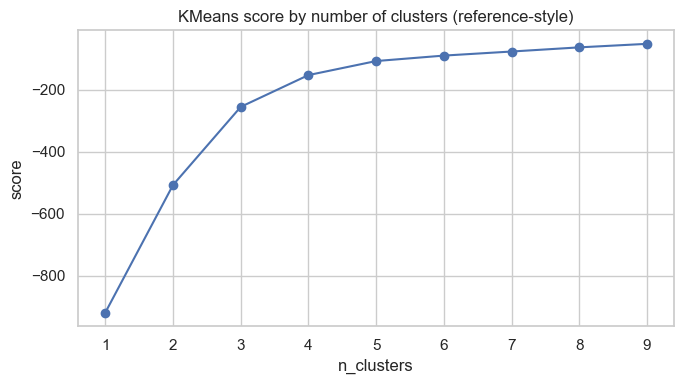

cluster_ref counts:
cluster_ref
0     82
1    196
2     50
3    131
Name: count, dtype: int64

anomaly_kmeans_ref counts:
anomaly_kmeans_ref
0    455
1      4
Name: count, dtype: int64
outlier threshold: 1.5082


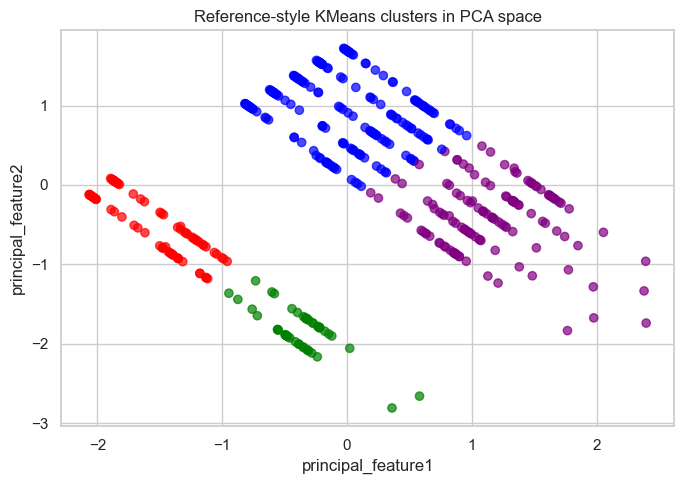

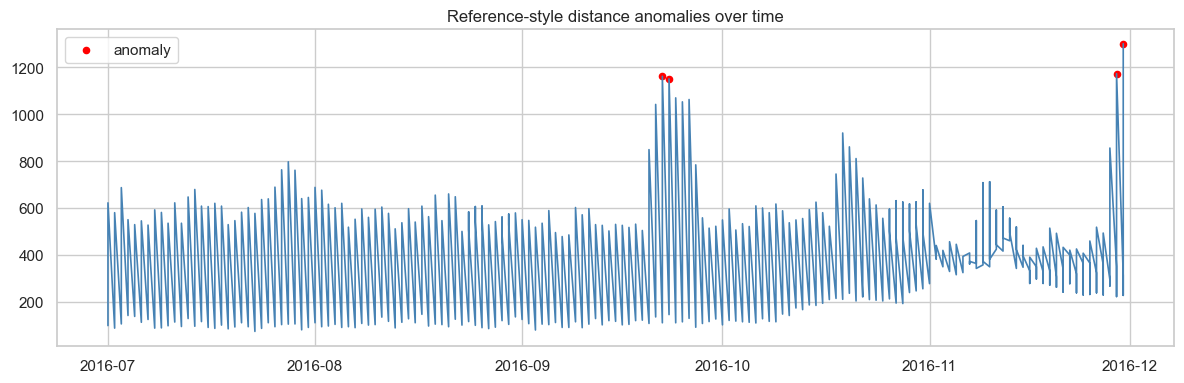

,brand_id,brand_code,anomalies_count
0,29,0,4
1,178,1,0
2,5152,2,0


In [8]:
def get_distance_by_point(data_2d: pd.DataFrame, model: KMeans) -> pd.Series:
    # Distance from each point to its assigned cluster center.
    distances = []
    for i in range(len(data_2d)):
        point = np.array(data_2d.loc[i])
        center = model.cluster_centers_[model.labels_[i]]
        distances.append(np.linalg.norm(point - center))
    return pd.Series(distances)


# Кластеризация
cluster_ref_df = sales_df[sales_df['brand_id'].isin(brands.keys())].copy()
cluster_ref_df['date'] = pd.to_datetime(cluster_ref_df['date'])
cluster_ref_df['hours'] = 12  # Данные дневные; для совместимости с шаблоном фиксируем "полдень".
cluster_ref_df['daylight'] = 1
cluster_ref_df['DayOfTheWeek'] = cluster_ref_df['date'].dt.dayofweek
cluster_ref_df['WeekDay'] = (cluster_ref_df['DayOfTheWeek'] < 5).astype(int)
cluster_ref_df['brand_code'] = cluster_ref_df['brand_id'].map({29: 0, 178: 1, 5152: 2})
cluster_ref_df['time_epoch'] = (
    cluster_ref_df['date'].astype('int64') // 100_000_000_000
).astype('int64')
cluster_ref_df = cluster_ref_df.rename(columns={'receipts_count': 'value'})

# Берем полезные признаки и стандартизуем
ref_data = cluster_ref_df[['value', 'hours', 'daylight', 'DayOfTheWeek', 'WeekDay', 'brand_code']]
std_scaler = preprocessing.StandardScaler().fit(ref_data)
np_scaled = std_scaler.transform(ref_data)
ref_data = pd.DataFrame(np_scaled)

# Уменьшаем до 2 компонент PCA и нормализуем.
pca_ref = PCA(n_components=2, random_state=42)
ref_data = pca_ref.fit_transform(ref_data)
ref_data = pd.DataFrame(ref_data)

post_pca_scaler = preprocessing.StandardScaler().fit(ref_data)
np_scaled = post_pca_scaler.transform(ref_data)
ref_data = pd.DataFrame(np_scaled)

# Подбор числа кластеров по score (inertia-like criterion).
n_cluster = range(1, 10)
kmeans_models = [KMeans(n_clusters=j, random_state=42, n_init=20).fit(ref_data) for j in n_cluster]
scores = [km.score(ref_data) for km in kmeans_models]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(n_cluster), scores, marker='o')
ax.set_title('KMeans score by number of clusters (reference-style)')
ax.set_xlabel('n_clusters')
ax.set_ylabel('score')
plt.tight_layout()
plt.show()

# кластера
kmeans_ref = kmeans_models[3]
cluster_ref_df['cluster_ref'] = kmeans_ref.predict(ref_data)
cluster_ref_df['principal_feature1'] = ref_data[0]
cluster_ref_df['principal_feature2'] = ref_data[1]

# Distance-based anomalies (но порог берем из top-fraction, а не фиксированным числом).
outliers_fraction_ref = 0.01
distance = get_distance_by_point(ref_data, kmeans_ref)
number_of_outliers = max(1, int(outliers_fraction_ref * len(distance)))
threshold = distance.nlargest(number_of_outliers).min()
cluster_ref_df['anomaly_kmeans_ref'] = (distance >= threshold).astype(int)

print('cluster_ref counts:')
print(cluster_ref_df['cluster_ref'].value_counts().sort_index())
print('\nanomaly_kmeans_ref counts:')
print(cluster_ref_df['anomaly_kmeans_ref'].value_counts())
print(f'outlier threshold: {threshold:.4f}')

# Визуализация кластеров в PCA-пространстве.
fig, ax = plt.subplots(figsize=(7, 5))
palette = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}
ax.scatter(
    cluster_ref_df['principal_feature1'],
    cluster_ref_df['principal_feature2'],
    c=cluster_ref_df['cluster_ref'].map(palette),
    alpha=0.7
)
ax.set_title('Reference-style KMeans clusters in PCA space')
ax.set_xlabel('principal_feature1')
ax.set_ylabel('principal_feature2')
plt.tight_layout()
plt.show()

# Визуализация аномалий во времени.
fig, ax = plt.subplots(figsize=(12, 4))
anom_points = cluster_ref_df.loc[cluster_ref_df['anomaly_kmeans_ref'] == 1, ['date', 'value']]
ax.plot(cluster_ref_df['date'], cluster_ref_df['value'], color='steelblue', linewidth=1.2)
ax.scatter(anom_points['date'], anom_points['value'], color='red', s=20, label='anomaly')
ax.set_title('Reference-style distance anomalies over time')
ax.legend()
plt.tight_layout()
plt.show()

# Расклад аномалий по брендам.
display(
    cluster_ref_df.groupby(['brand_id', 'brand_name' if 'brand_name' in cluster_ref_df.columns else 'brand_code'])['anomaly_kmeans_ref']
    .sum()
    .reset_index(name='anomalies_count')
)

### Интерпретация найденных 4 аномалий (reference-style KMeans)

- выявлено `4` аномалии из `459` наблюдений (примерно `1%` выборки).
- Все `4` аномалии отнесены к бренду `lipton` (`brand_id = 29`), для `ahmad` и `may` в этом подходе аномалий не найдено.
- Это означает, что в PCA-пространстве признаков самые удаленные от центров кластеров точки принадлежат именно ряду `lipton`.
- Практически это скорее индикатор редких пиков/скачков в динамике `lipton`, а не подтверждение эффекта эфира для `ahmad`.

# Итоговый вывод по проекту

В работе были последовательно выполнены: анализ динамики продаж, расчет описательных статистик, проверка выбросов, сравнение периодов до и после эфиров передачи «Что? Где? Когда?», построение baseline-модели CatBoost и чистый тест эффекта эфира на остатках.

По сырым продажам локальные всплески действительно наблюдаются, однако после учета тренда, календарных факторов и волатильности статистически значимого эффекта эфира для бренда `ahmad` не выявлено. Аналогично, чистый тест на остатках не подтвердил устойчивый эффект и для остальных брендов.

Кластеризация в reference-style KMeans выделила 4 аномалии из 459 наблюдений (около 1%), и все они относятся к `lipton` (`brand_id = 29`). Для `ahmad` и `may` в этом подходе аномалий не найдено.

Итог: в рамках доступного датасета гипотеза о заметном рекламном эффекте передачи на продажи чая `ahmad` не подтверждается.